Merge dataset tiktok+yt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

BASE = "/content/drive/MyDrive/viral_agent"
META_DIR = f"{BASE}/datasets/metadata"
tiktok_path = f"{META_DIR}/tiktok_metadata0.csv"
youtube_path = f"{META_DIR}/youtube_metadata.csv"
youtube_path0 = f"{META_DIR}/youtube_metadata0.csv"

df_tt = pd.read_csv(tiktok_path)
df_yt = pd.read_csv(youtube_path)
df_yt0 = pd.read_csv(youtube_path0)

df = pd.concat([df_tt, df_yt,df_yt0], ignore_index=True)
print("Loaded and merged TikTok + YouTube datasets")

Loaded and merged TikTok + YouTube datasets


In [ ]:
df.shape

(1190, 12)

In [ ]:
df.to_csv('/content/drive/MyDrive/viral_agent/datasets/merged_metadata0.csv', index=False)

In [ ]:
import pandas as pd
import os
df=pd.read_csv('/content/drive/MyDrive/viral_agent/features/final_model_dataset.csv')

In [ ]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1190, 12)


,platform,video_id,url,creator_username,caption_or_title,publish_date,views,likes,comments,duration_seconds,local_video_path,source_query
0,tiktok,7629028827397639441,https://www.tiktok.com/@cothon.media/video/762...,cothon.media,فازات ماركيتينج - Marketing Tricks #marketing ...,20260415,104400,5328,4,27,/content/drive/MyDrive/viral_agent/datasets/ra...,manual_link_list
1,tiktok,7630978763202874646,https://www.tiktok.com/@zied.khemiriii/video/7...,zied.khemiriii,Khatina chabeb l photo dumps #fyp #tunisia🇹🇳 #...,20260420,117400,7670,136,58,/content/drive/MyDrive/viral_agent/datasets/ra...,manual_link_list
2,tiktok,7629440233678982407,https://www.tiktok.com/@ismaailvisuals5/video/...,ismaailvisuals5,AI just spoke Tunisian Arabic fluently 😳 No ac...,20260416,23100,1332,635,32,/content/drive/MyDrive/viral_agent/datasets/ra...,manual_link_list
3,tiktok,7629160277929463071,https://www.tiktok.com/@brookepetersoneq/video...,brookepetersoneq,perfectly made 💛 #equestrian #horses,20260416,468100,94800,80,6,/content/drive/MyDrive/viral_agent/datasets/ra...,manual_link_list
4,tiktok,7614962372758850837,https://www.tiktok.com/@mymy_x_06/video/761496...,mymy_x_06,I will never make a promise that I can’t keep#...,20260308,270100,38500,133,14,/content/drive/MyDrive/viral_agent/datasets/ra...,manual_link_list


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   platform          1190 non-null   object
 1   video_id          1190 non-null   object
 2   url               1190 non-null   object
 3   creator_username  1190 non-null   object
 4   caption_or_title  1190 non-null   object
 5   publish_date      1190 non-null   object
 6   views             1190 non-null   int64 
 7   likes             1190 non-null   int64 
 8   comments          1190 non-null   int64 
 9   duration_seconds  1190 non-null   int64 
 10  local_video_path  1176 non-null   object
 11  source_query      1190 non-null   object
dtypes: int64(4), object(8)
memory usage: 111.7+ KB


In [ ]:
df.isnull().sum()

,0
platform,0
video_id,0
url,0
creator_username,0
caption_or_title,0
publish_date,0
views,0
likes,0
comments,0
duration_seconds,0


In [ ]:
# remove missing videos
df = df[df['local_video_path'].notna()]

# Reset index
df = df.reset_index(drop=True)

print("After removing missing videos:", df.shape)

After removing missing videos: (1176, 12)


In [ ]:
df = df.rename(columns={
    "creator_username": "creator",
    "caption_or_title": "title"
})

In [ ]:
df['publish_date']

,publish_date
0,20260415
1,20260420
2,20260416
3,20260416
4,20260308
...,...
1171,2022-05-06T11:28:39Z
1172,2022-08-05T08:18:10Z
1173,2023-01-27T03:44:11Z
1174,2022-04-27T12:54:50Z


In [ ]:
def parse_date(x):
    x = str(x)

    # Case 1: TikTok format (YYYYMMDD)
    if x.isdigit() and len(x) == 8:
        return pd.to_datetime(x, format="%Y%m%d", errors='coerce')

    # Case 2: YouTube ISO format
    return pd.to_datetime(x, errors='coerce')

df['publish_date'] = df['publish_date'].apply(parse_date)

In [ ]:
df['publish_date']


,publish_date
0,2026-04-15 00:00:00
1,2026-04-20 00:00:00
2,2026-04-16 00:00:00
3,2026-04-16 00:00:00
4,2026-03-08 00:00:00
...,...
1171,2022-05-06 11:28:39+00:00
1172,2022-08-05 08:18:10+00:00
1173,2023-01-27 03:44:11+00:00
1174,2022-04-27 12:54:50+00:00


In [ ]:
df['publish_date'].dtype

dtype('O')

In [ ]:
df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce', utc=True)

In [ ]:
df['publish_date'] = df['publish_date'].dt.tz_localize(None)

In [ ]:
df['publish_date']

,publish_date
0,2026-04-15 00:00:00
1,2026-04-20 00:00:00
2,2026-04-16 00:00:00
3,2026-04-16 00:00:00
4,2026-03-08 00:00:00
...,...
1171,2022-05-06 11:28:39
1172,2022-08-05 08:18:10
1173,2023-01-27 03:44:11
1174,2022-04-27 12:54:50


In [ ]:
df['year'] = df['publish_date'].dt.year
df['month'] = df['publish_date'].dt.month
df['day'] = df['publish_date'].dt.day
df['day_of_week'] = df['publish_date'].dt.dayofweek
df['hour'] = df['publish_date'].dt.hour

In [ ]:
# Engagement rate (core signal)
df['engagement_rate'] = (df['likes'] + df['comments']) / df['views']

In [ ]:
# Like ratio
df['like_rate'] = df['likes'] / df['views']

In [ ]:
# Comment ratio
df['comment_rate'] = df['comments'] / df['views']

In [ ]:
# Log views (helps model stability)
import numpy as np
df['log_views'] = np.log1p(df['views'])

In [ ]:
print(df[['views', 'likes', 'comments', 'engagement_rate']].describe())

              views         likes      comments  engagement_rate
count  1.176000e+03  1.176000e+03   1176.000000     1.176000e+03
mean   4.041540e+07  7.848995e+05   2222.369898              inf
std    1.503924e+08  1.758121e+06   7003.400588              NaN
min    0.000000e+00  0.000000e+00      0.000000     8.415346e-07
25%    1.487500e+05  8.032500e+03     38.000000     2.792445e-02
50%    7.938500e+05  7.315000e+04    193.500000     6.555940e-02
75%    1.454667e+07  7.228420e+05   1564.750000     1.311942e-01
max    3.155660e+09  2.393848e+07  85423.000000              inf


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   platform          1176 non-null   object        
 1   video_id          1176 non-null   object        
 2   url               1176 non-null   object        
 3   creator           1176 non-null   object        
 4   title             1176 non-null   object        
 5   publish_date      1176 non-null   datetime64[ns]
 6   views             1176 non-null   int64         
 7   likes             1176 non-null   int64         
 8   comments          1176 non-null   int64         
 9   duration_seconds  1176 non-null   int64         
 10  local_video_path  1176 non-null   object        
 11  source_query      1176 non-null   object        
 12  year              1176 non-null   int32         
 13  month             1176 non-null   int32         
 14  day               1176 n

In [ ]:
df.describe()

,publish_date,views,likes,comments,duration_seconds,year,month,day,day_of_week,hour,engagement_rate,like_rate,comment_rate,log_views
count,1176,1.176000e+03,1.176000e+03,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1.176000e+03,1174.000000,1176.000000,1176.000000
mean,2025-05-05 20:56:17.507653120,4.041540e+07,7.848995e+05,2222.369898,21.532313,2024.984694,4.846939,15.476190,2.926020,2.598639,inf,0.081609,inf,14.034003
min,2020-05-20 00:00:00,0.000000e+00,0.000000e+00,0.000000,4.000000,2020.000000,1.000000,1.000000,0.000000,0.000000,8.415346e-07,0.000000,0.000000,0.000000
25%,2024-11-07 11:28:49.750000128,1.487500e+05,8.032500e+03,38.000000,8.000000,2024.000000,3.000000,8.000000,1.000000,0.000000,2.792445e-02,0.027511,0.000077,11.910028
50%,2026-02-18 00:00:00,7.938500e+05,7.315000e+04,193.500000,13.000000,2026.000000,4.000000,16.000000,3.000000,0.000000,6.555940e-02,0.064491,0.000188,13.584650
75%,2026-04-06 00:00:00,1.454667e+07,7.228420e+05,1564.750000,23.000000,2026.000000,6.000000,23.000000,5.000000,0.000000,1.311942e-01,0.129903,0.000459,16.492849
max,2026-05-01 00:00:00,3.155660e+09,2.393848e+07,85423.000000,448.000000,2026.000000,12.000000,31.000000,6.000000,23.000000,inf,0.277581,inf,21.872463
std,NaN,1.503924e+08,1.758121e+06,7003.400588,29.488097,1.492599,2.935396,8.521379,1.983027,5.245672,NaN,0.063437,NaN,3.154453


In [ ]:
df= df.drop(columns=['publish_date'])

In [ ]:
df.describe()

,views,likes,comments,duration_seconds,year,month,day,day_of_week,hour,engagement_rate,like_rate,comment_rate,log_views
count,1.176000e+03,1.176000e+03,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1.176000e+03,1174.000000,1176.000000,1176.000000
mean,4.041540e+07,7.848995e+05,2222.369898,21.532313,2024.984694,4.846939,15.476190,2.926020,2.598639,inf,0.081609,inf,14.034003
std,1.503924e+08,1.758121e+06,7003.400588,29.488097,1.492599,2.935396,8.521379,1.983027,5.245672,NaN,0.063437,NaN,3.154453
min,0.000000e+00,0.000000e+00,0.000000,4.000000,2020.000000,1.000000,1.000000,0.000000,0.000000,8.415346e-07,0.000000,0.000000,0.000000
25%,1.487500e+05,8.032500e+03,38.000000,8.000000,2024.000000,3.000000,8.000000,1.000000,0.000000,2.792445e-02,0.027511,0.000077,11.910028
50%,7.938500e+05,7.315000e+04,193.500000,13.000000,2026.000000,4.000000,16.000000,3.000000,0.000000,6.555940e-02,0.064491,0.000188,13.584650
75%,1.454667e+07,7.228420e+05,1564.750000,23.000000,2026.000000,6.000000,23.000000,5.000000,0.000000,1.311942e-01,0.129903,0.000459,16.492849
max,3.155660e+09,2.393848e+07,85423.000000,448.000000,2026.000000,12.000000,31.000000,6.000000,23.000000,inf,0.277581,inf,21.872463


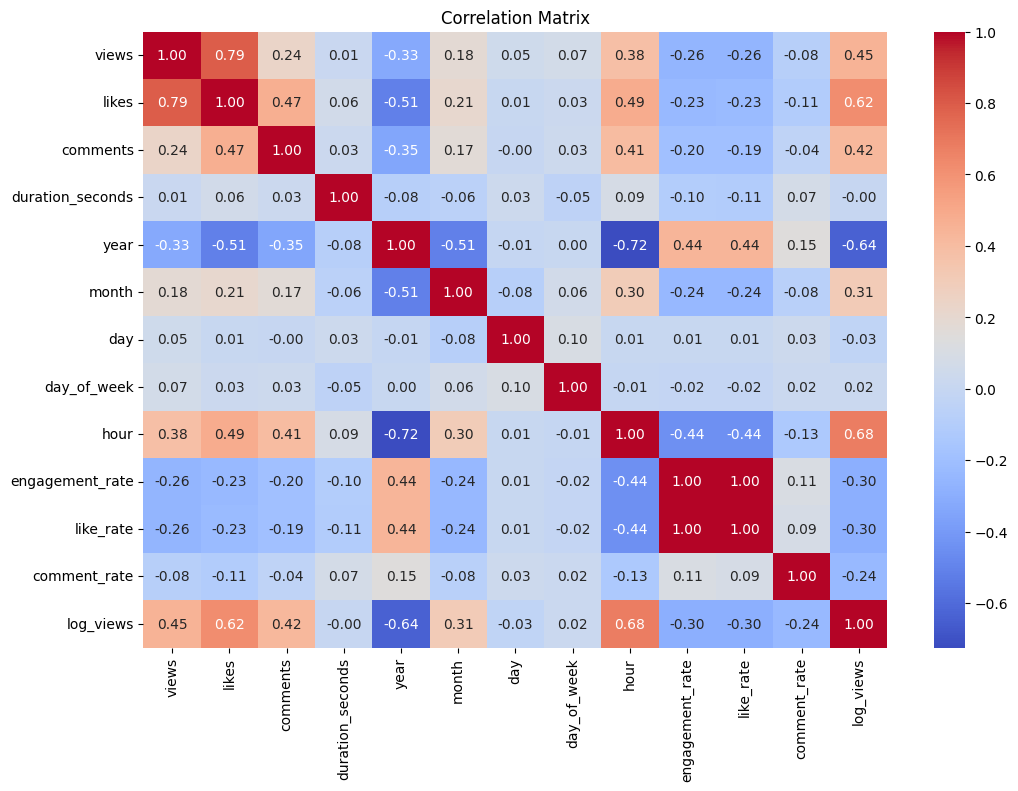

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
df['platform'].value_counts()

,count
platform,
tiktok,886
youtube,290


In [ ]:
df["title"]

,title
0,فازات ماركيتينج - Marketing Tricks #marketing ...
1,Khatina chabeb l photo dumps #fyp #tunisia🇹🇳 #...
2,AI just spoke Tunisian Arabic fluently 😳 No ac...
3,perfectly made 💛 #equestrian #horses
4,I will never make a promise that I can’t keep#...
...,...
1171,Three rules for a happy life ! | Buddhism In ...
1172,| दृष्टि IAS से मिलता है Gandhav को Motivation...
1173,MAN BECOME POWERFUL…/sigma rule/motivation #sh...
1174,🔥Inspirational quote status | Motivational sho...


In [ ]:
df["title_length"] = df["title"].apply(len)

In [ ]:
# 2. Word count
df["word_count"] = df["title"].apply(lambda x: len(x.split()))

In [ ]:
# 3. Has hashtag (binary)
df["has_hashtag"] = df["title"].apply(lambda x: 1 if "#" in x else 0)

In [ ]:
# 4. Creator experience (very important)
df["creator_video_count"] = df.groupby("creator")["video_id"].transform("count")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   platform             1176 non-null   object 
 1   video_id             1176 non-null   object 
 2   url                  1176 non-null   object 
 3   creator              1176 non-null   object 
 4   title                1176 non-null   object 
 5   views                1176 non-null   int64  
 6   likes                1176 non-null   int64  
 7   comments             1176 non-null   int64  
 8   duration_seconds     1176 non-null   int64  
 9   local_video_path     1176 non-null   object 
 10  source_query         1176 non-null   object 
 11  year                 1176 non-null   int32  
 12  month                1176 non-null   int32  
 13  day                  1176 non-null   int32  
 14  day_of_week          1176 non-null   int32  
 15  hour                 1176 non-null   i

In [ ]:
df.to_csv('/content/drive/MyDrive/viral_agent/datasets/metadata/merged_metadata1.csv', index=False)